In [1]:
# Install required libraries
!pip install torch torchvision transformers scikit-learn opencv-python matplotlib seaborn pandas tqdm

In [2]:
# Import all libraries
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets, models
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import cv2
import os
from torch import nn
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm

# Check GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")


Using device: cuda
PyTorch version: 2.10.0+cu128


In [3]:
# Download GTSRB dataset directly from torchvision
print("Downloading GTSRB dataset...")

# Download training set
train_dataset_full = datasets.GTSRB(
    root='./data',
    split='train',
    download=True
)

# Download test set
test_dataset = datasets.GTSRB(
    root='./data',
    split='test',
    download=True
)

print(f"Training samples: {len(train_dataset_full)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Number of classes: 43")


100%|██████████| 187M/187M [00:18<00:00, 10.3MB/s]
100%|██████████| 89.0M/89.0M [00:08<00:00, 10.9MB/s]
100%|██████████| 99.6k/99.6k [00:00<00:00, 212kB/s]


Training samples: 26640
Test samples: 12630
Number of classes: 43


In [4]:
# Define transforms
transform_train = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

transform_test = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Reload datasets with transforms
train_dataset_full = datasets.GTSRB(
    root='./data',
    split='train',
    transform=transform_train,
    download=False
)

test_dataset = datasets.GTSRB(
    root='./data',
    split='test',
    transform=transform_test,
    download=False
)

# Split training into train and validation (90% train, 10% val)
train_size = int(0.9 * len(train_dataset_full))
val_size = len(train_dataset_full) - train_size

train_dataset, val_dataset = random_split(
    train_dataset_full,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Training samples: 23976
Validation samples: 2664
Test samples: 12630


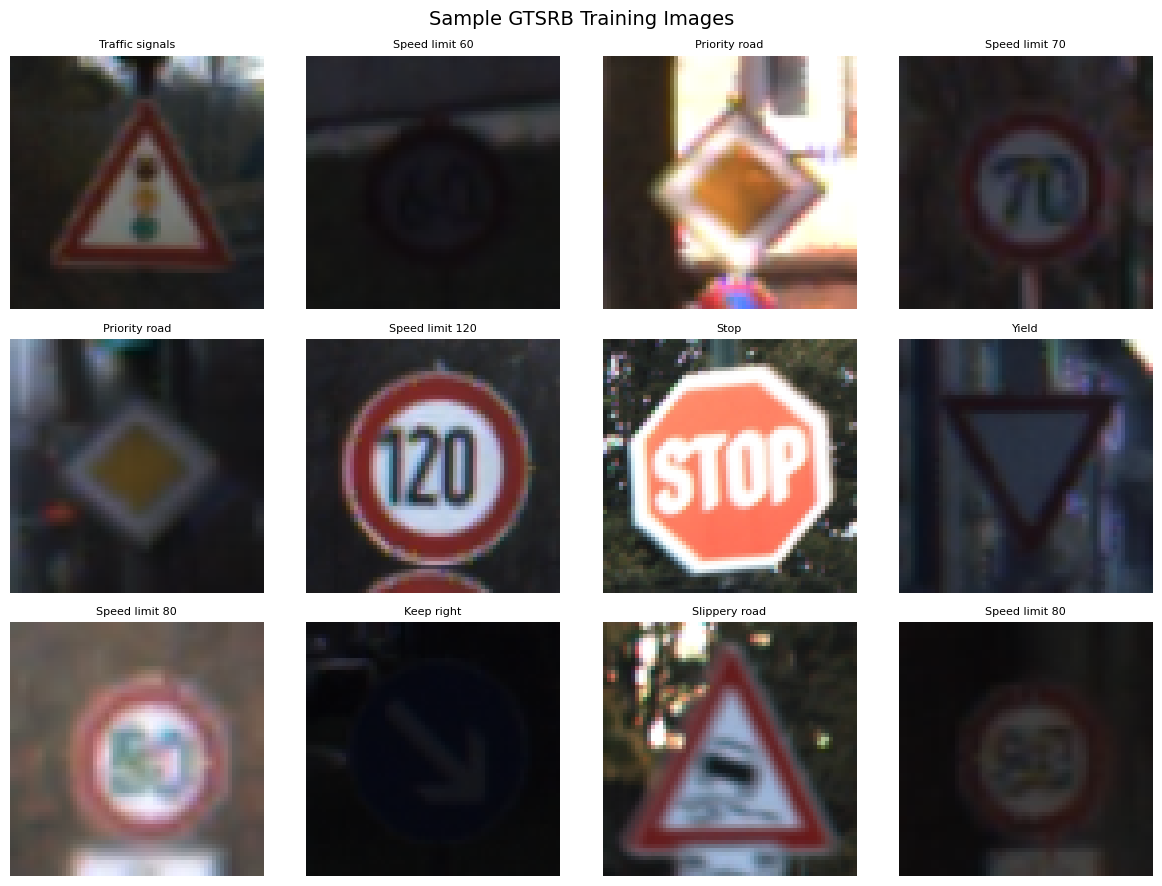

Sample images saved!


In [5]:
# Visualize sample images from the dataset
import matplotlib.pyplot as plt
import numpy as np

# Class names for GTSRB
class_names = [
    'Speed limit 20', 'Speed limit 30', 'Speed limit 50', 'Speed limit 60',
    'Speed limit 70', 'Speed limit 80', 'End speed limit 80', 'Speed limit 100',
    'Speed limit 120', 'No passing', 'No passing >3.5t', 'Right of way',
    'Priority road', 'Yield', 'Stop', 'No vehicles', 'No vehicles >3.5t',
    'No entry', 'General caution', 'Dangerous curve left', 'Dangerous curve right',
    'Double curve', 'Bumpy road', 'Slippery road', 'Road narrows right',
    'Road work', 'Traffic signals', 'Pedestrians', 'Children crossing',
    'Bicycles crossing', 'Beware ice/snow', 'Wild animals', 'End all limits',
    'Turn right ahead', 'Turn left ahead', 'Ahead only', 'Go straight or right',
    'Go straight or left', 'Keep right', 'Keep left', 'Roundabout',
    'End no passing', 'End no passing >3.5t'
]

# Get a batch of images
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Denormalize images for display
def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return tensor * std + mean

# Plot 12 sample images
fig, axes = plt.subplots(3, 4, figsize=(12, 9))
for i, ax in enumerate(axes.flat):
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.set_title(class_names[labels[i]], fontsize=8)
    ax.axis('off')

plt.suptitle('Sample GTSRB Training Images', fontsize=14)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sample images saved!")

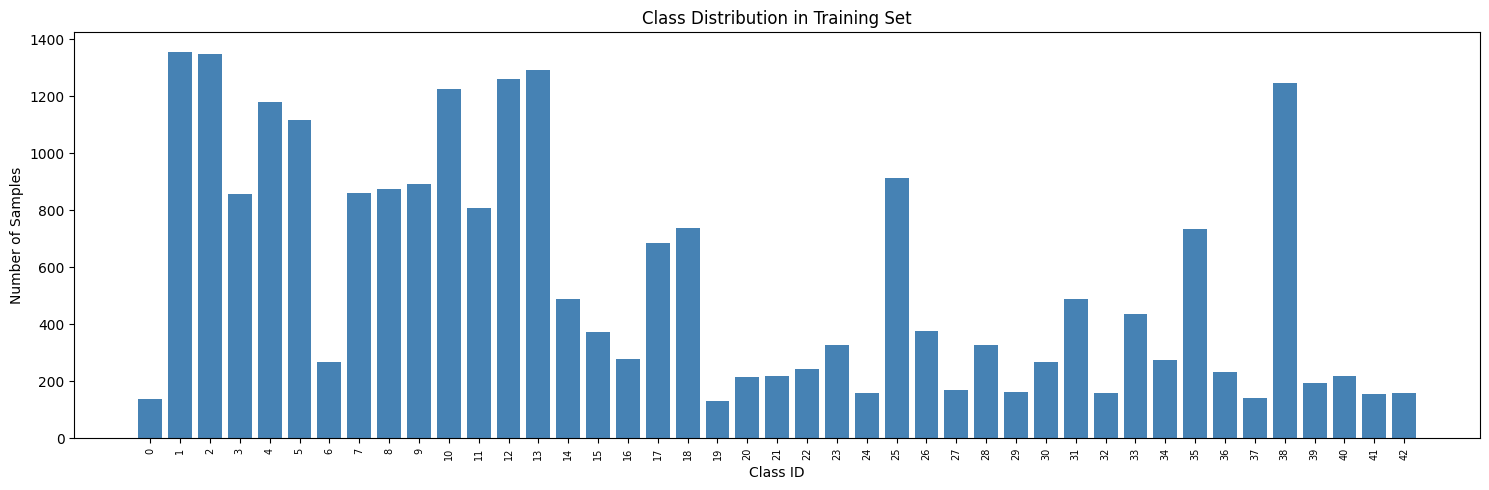

Most common class: Speed limit 30 (1356 samples)
Least common class: Dangerous curve left (132 samples)


In [6]:
# Plot class distribution
class_counts = [0] * 43

for _, label in train_dataset:
    class_counts[label] += 1

plt.figure(figsize=(15, 5))
plt.bar(range(43), class_counts, color='steelblue')
plt.xlabel('Class ID')
plt.ylabel('Number of Samples')
plt.title('Class Distribution in Training Set')
plt.xticks(range(43), rotation=90, fontsize=7)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Most common class: {class_names[np.argmax(class_counts)]} ({max(class_counts)} samples)")
print(f"Least common class: {class_names[np.argmin(class_counts)]} ({min(class_counts)} samples)")


In [7]:
import cv2
import numpy as np
from PIL import Image
import torchvision.transforms.functional as TF

def apply_gaussian_blur(image, severity=1):
    """Apply Gaussian blur to simulate motion/focus blur"""
    kernel_sizes = [3, 5, 7, 9, 11]
    ksize = kernel_sizes[severity - 1]
    img_array = np.array(image)
    blurred = cv2.GaussianBlur(img_array, (ksize, ksize), 0)
    return Image.fromarray(blurred)

def apply_noise(image, severity=1):
    """Add Gaussian noise to simulate sensor noise"""
    noise_levels = [5, 10, 20, 35, 50]
    noise_std = noise_levels[severity - 1]
    img_array = np.array(image).astype(np.float32)
    noise = np.random.normal(0, noise_std, img_array.shape)
    noisy = np.clip(img_array + noise, 0, 255).astype(np.uint8)
    return Image.fromarray(noisy)

def apply_brightness(image, severity=1):
    """Reduce brightness to simulate low light/night driving"""
    brightness_factors = [0.8, 0.6, 0.4, 0.2, 0.1]
    factor = brightness_factors[severity - 1]
    img_array = np.array(image).astype(np.float32)
    darkened = np.clip(img_array * factor, 0, 255).astype(np.uint8)
    return Image.fromarray(darkened)

def apply_fog(image, severity=1):
    """Simulate fog effect"""
    fog_intensities = [0.2, 0.35, 0.5, 0.65, 0.8]
    fog_intensity = fog_intensities[severity - 1]
    img_array = np.array(image).astype(np.float32)
    fog_layer = np.ones_like(img_array) * 255
    fogged = img_array * (1 - fog_intensity) + fog_layer * fog_intensity
    fogged = np.clip(fogged, 0, 255).astype(np.uint8)
    return Image.fromarray(fogged)

print("Degradation functions defined successfully!")

Degradation functions defined successfully!


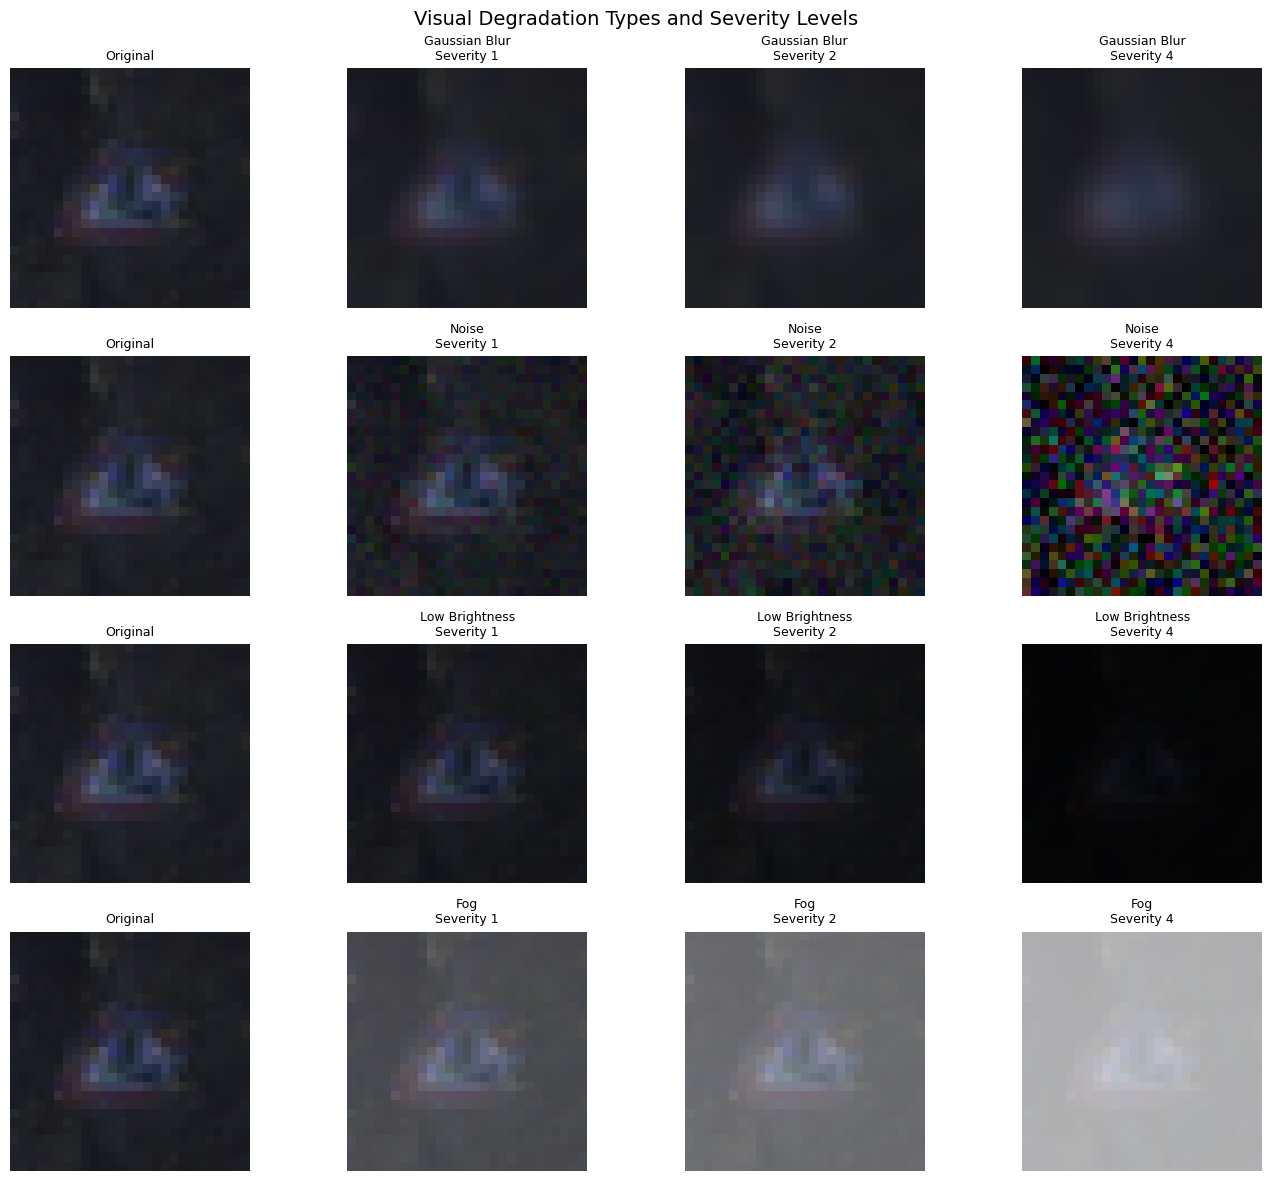

Degradation visualization saved!


In [8]:
# Visualize all 4 degradations at 3 severity levels
# Get a clean sample image
sample_loader = DataLoader(test_dataset, batch_size=1, shuffle=True)
sample_iter = iter(sample_loader)

# Get raw image without transforms for visualization
raw_test = datasets.GTSRB(root='./data', split='test', download=False)
raw_image, raw_label = raw_test[50]  # pick sample image

fig, axes = plt.subplots(4, 4, figsize=(14, 12))

degradations = [apply_gaussian_blur, apply_noise, apply_brightness, apply_fog]
degradation_names = ['Gaussian Blur', 'Noise', 'Low Brightness', 'Fog']
severities = [1, 2, 4]

for row, (deg_func, deg_name) in enumerate(zip(degradations, degradation_names)):
    # Original
    axes[row, 0].imshow(raw_image)
    axes[row, 0].set_title(f'Original', fontsize=9)
    axes[row, 0].axis('off')

    # 3 severity levels
    for col, severity in enumerate(severities):
        degraded = deg_func(raw_image, severity=severity)
        axes[row, col+1].imshow(degraded)
        axes[row, col+1].set_title(f'{deg_name}\nSeverity {severity}', fontsize=9)
        axes[row, col+1].axis('off')

plt.suptitle('Visual Degradation Types and Severity Levels', fontsize=14)
plt.tight_layout()
plt.savefig('degradation_examples.png', dpi=150, bbox_inches='tight')
plt.show()
print("Degradation visualization saved!")


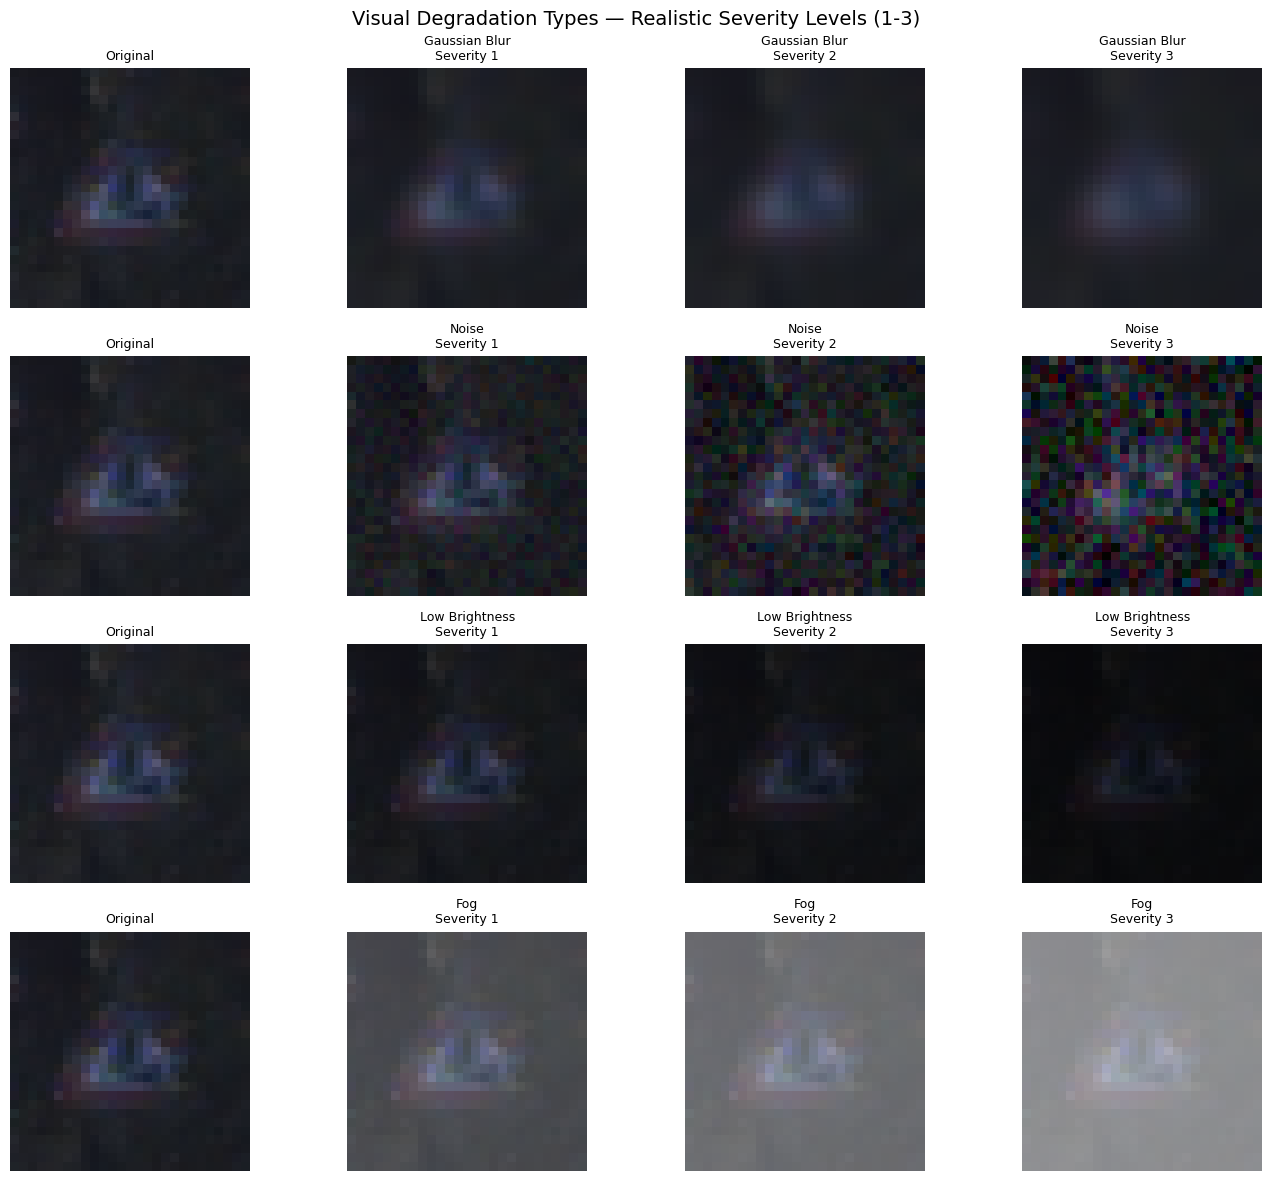

Revised degradation visualization saved!


In [9]:
# Revised visualization with realistic severity levels only (1, 2, 3)
fig, axes = plt.subplots(4, 4, figsize=(14, 12))

degradations = [apply_gaussian_blur, apply_noise, apply_brightness, apply_fog]
degradation_names = ['Gaussian Blur', 'Noise', 'Low Brightness', 'Fog']
severities = [1, 2, 3]

for row, (deg_func, deg_name) in enumerate(zip(degradations, degradation_names)):
    # Original
    axes[row, 0].imshow(raw_image)
    axes[row, 0].set_title('Original', fontsize=9)
    axes[row, 0].axis('off')

    # 3 realistic severity levels
    for col, severity in enumerate(severities):
        degraded = deg_func(raw_image, severity=severity)
        axes[row, col+1].imshow(degraded)
        axes[row, col+1].set_title(f'{deg_name}\nSeverity {severity}', fontsize=9)
        axes[row, col+1].axis('off')

plt.suptitle('Visual Degradation Types — Realistic Severity Levels (1-3)', fontsize=14)
plt.tight_layout()
plt.savefig('degradation_examples_revised.png', dpi=150, bbox_inches='tight')
plt.show()
print("Revised degradation visualization saved!")

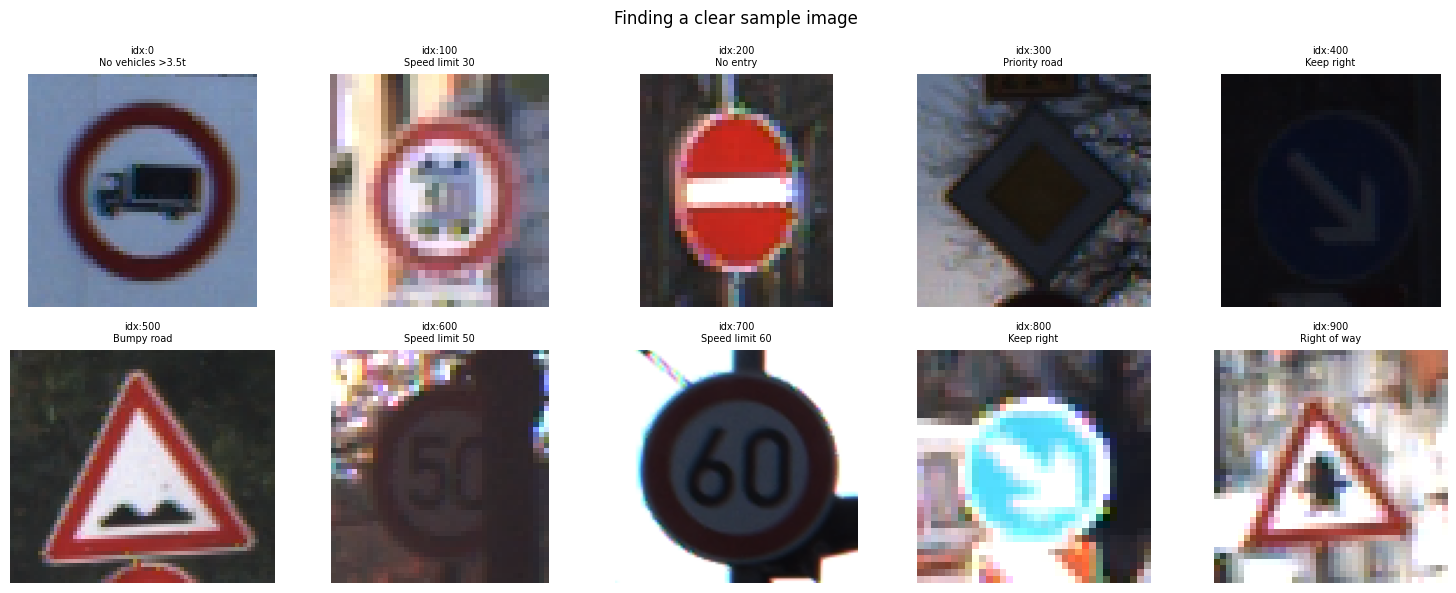

In [10]:
# Find a clearer sample image for visualization
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flat):
    raw_image_temp, label_temp = raw_test[i * 100]
    ax.imshow(raw_image_temp)
    ax.set_title(f'idx:{i*100}\n{class_names[label_temp]}', fontsize=7)
    ax.axis('off')

plt.suptitle('Finding a clear sample image', fontsize=12)
plt.tight_layout()
plt.show()

In [11]:
# Use idx:500 which is the brightest clearest image
raw_image, raw_label = raw_test[500]

fig, axes = plt.subplots(4, 4, figsize=(14, 12))

degradations = [apply_gaussian_blur, apply_noise, apply_brightness, apply_fog]
degradation_names = ['Gaussian Blur', 'Noise', 'Low Brightness', 'Fog']
severities = [1, 2, 3]

for row, (deg_func, deg_name) in enumerate(zip(degradations, degradation_names)):
    # Original
    axes[row, 0].imshow(raw_image)
    axes[row, 0].set_title('Original', fontsize=9)
    axes[row, 0].axis('off')

    # 3 realistic severity levels
    for col, severity in enumerate(severities):
        degraded = deg_func(raw_image, severity=severity)
        axes[row, col+1].imshow(degraded)
        axes[row, col+1].set_title(f'{deg_name}\nSeverity {severity}', fontsize=9)
        axes[row, col+1].axis('off')

plt.suptitle('Visual Degradation Types — Realistic Severity Levels (1-3)', fontsize=14)
plt.tight_layout()
plt.savefig('degradation_examples_final.png', dpi=150, bbox_inches='tight')
plt.show()
print("Final degradation visualization sav

SyntaxError: unterminated string literal (detected at line 27) (17934641.py, line 27)

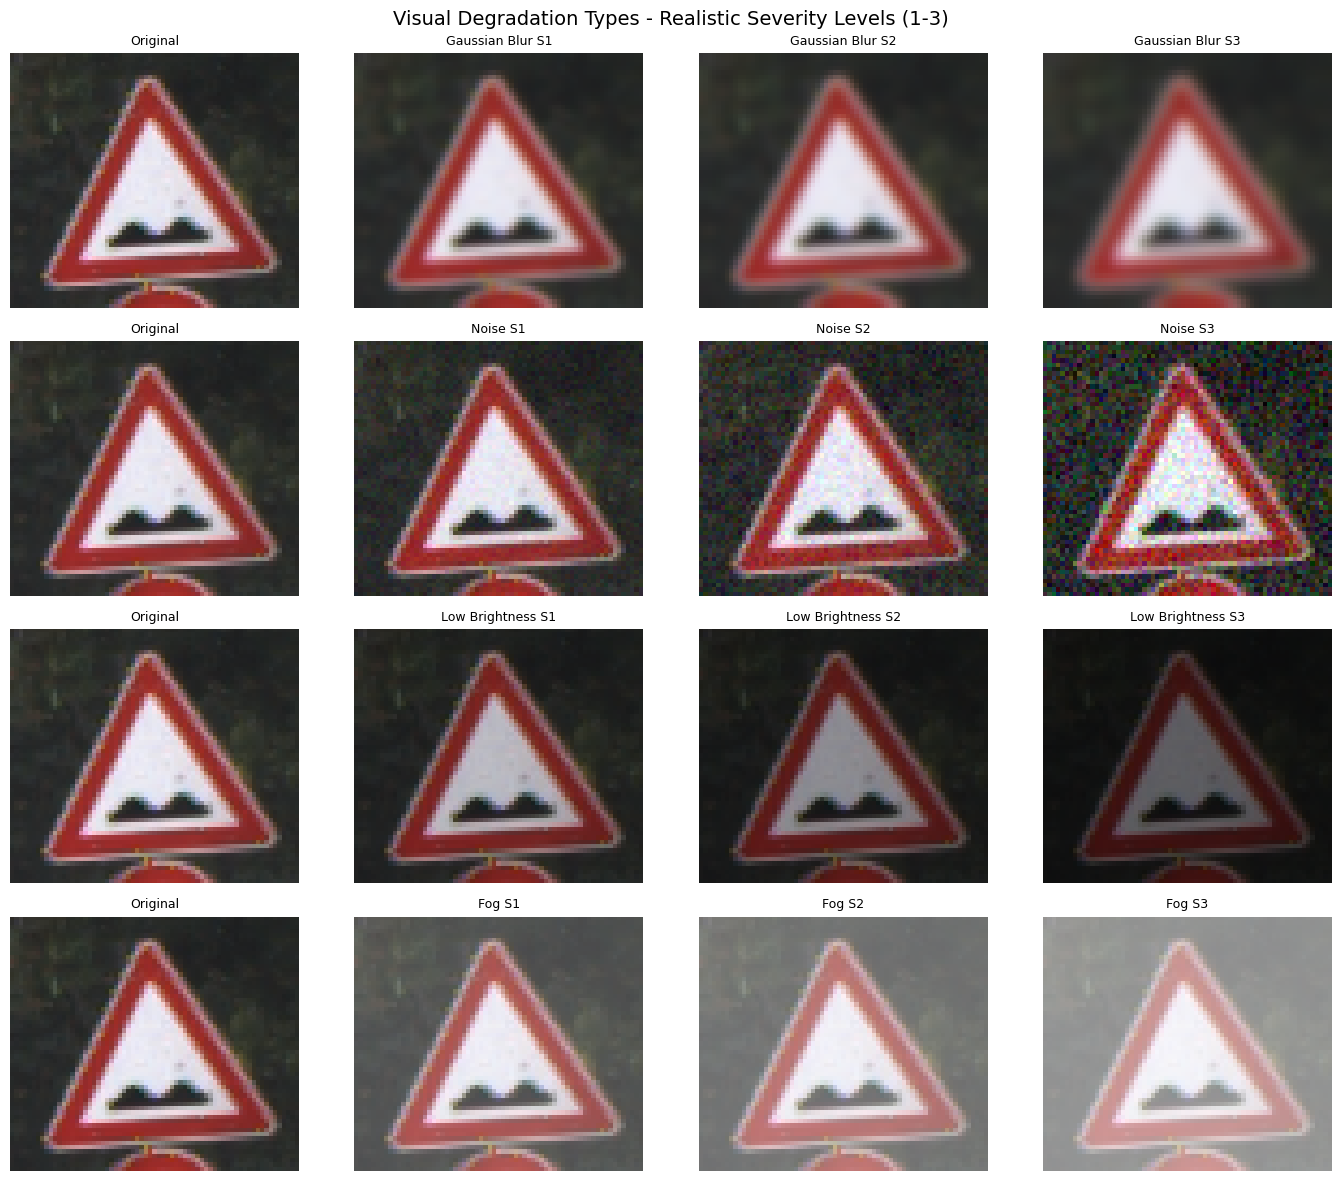

Done!


In [12]:
# Use idx:500 which is the brightest clearest image
raw_image, raw_label = raw_test[500]

fig, axes = plt.subplots(4, 4, figsize=(14, 12))

degradations = [apply_gaussian_blur, apply_noise, apply_brightness, apply_fog]
degradation_names = ['Gaussian Blur', 'Noise', 'Low Brightness', 'Fog']
severities = [1, 2, 3]

for row, (deg_func, deg_name) in enumerate(zip(degradations, degradation_names)):
    axes[row, 0].imshow(raw_image)
    axes[row, 0].set_title('Original', fontsize=9)
    axes[row, 0].axis('off')
    for col, severity in enumerate(severities):
        degraded = deg_func(raw_image, severity=severity)
        axes[row, col+1].imshow(degraded)
        axes[row, col+1].set_title(f'{deg_name} S{severity}', fontsize=9)
        axes[row, col+1].axis('off')

plt.suptitle('Visual Degradation Types - Realistic Severity Levels (1-3)', fontsize=14)
plt.tight_layout()
plt.savefig('degradation_examples_final.png', dpi=150, bbox_inches='tight')
plt.show()
print("Done!")